In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [9]:
df=pd.read_csv("kc_house_data.csv")
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [10]:
print(df.head())

           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     lo

In [11]:
print(df.columns)

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')


In [12]:
print("missing values")
print(df.isna().sum())

missing values
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [13]:
print("Zero values in bedrooms:",(df["bedrooms"]==0).sum())
print("Zero values in bedrooms:",(df["bedrooms"]==0).sum())

Zero values in bedrooms: 13
Zero values in bedrooms: 13


In [14]:
df["bedrooms"]=df["bedrooms"].replace(0,np.nan)
df["bedrooms"]=df["bedrooms"].replace(0,np.nan)

In [15]:
df.isna().sum()

id                0
date              0
price             0
bedrooms         13
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
grade             0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
zipcode           0
lat               0
long              0
sqft_living15     0
sqft_lot15        0
dtype: int64

In [16]:
df["bedrooms"]=df["bedrooms"].fillna(df['bedrooms'].mean())
df["bedrooms"]=df["bedrooms"].fillna(df['bedrooms'].median())

In [17]:
df.isna().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [18]:
df["date"]=pd.to_datetime(df["date"])

In [20]:
df["sale_year"]=df["date"].dt.year

In [21]:
df["house_age"]=df["sale_year"]-df["yr_built"]

In [24]:
df["years_since_renovation"]=np.where(
    df["yr_renovated"]>0,
    df["sale_year"]==df["yr_renovated"],
    np.nan
)

In [25]:
df[["date","sale_year","yr_built","yr_renovated","years_since_renovation"]].head()

,date,sale_year,yr_built,yr_renovated,years_since_renovation
0,2014-10-13,2014,1955,0,NaN
1,2014-12-09,2014,1951,1991,0.0
2,2015-02-25,2015,1933,0,NaN
3,2014-12-09,2014,1965,0,NaN
4,2015-02-18,2015,1987,0,NaN


In [26]:
df["price_per_sqft_living"]=df["price"]/df["sqft_living"]
df["price_per_sqft_lot"]=df["price"]/df["sqft_lot"]

In [27]:
df[["price","sqft_living","sqft_lot","price_per_sqft_living","price_per_sqft_lot"]]

,price,sqft_living,sqft_lot,price_per_sqft_living,price_per_sqft_lot
0,221900.0,1180,5650,188.050847,39.274336
1,538000.0,2570,7242,209.338521,74.288870
2,180000.0,770,10000,233.766234,18.000000
3,604000.0,1960,5000,308.163265,120.800000
4,510000.0,1680,8080,303.571429,63.118812
...,...,...,...,...,...
21608,360000.0,1530,1131,235.294118,318.302387
21609,400000.0,2310,5813,173.160173,68.811285
21610,402101.0,1020,1350,394.216667,297.852593
21611,400000.0,1600,2388,250.000000,167.504188


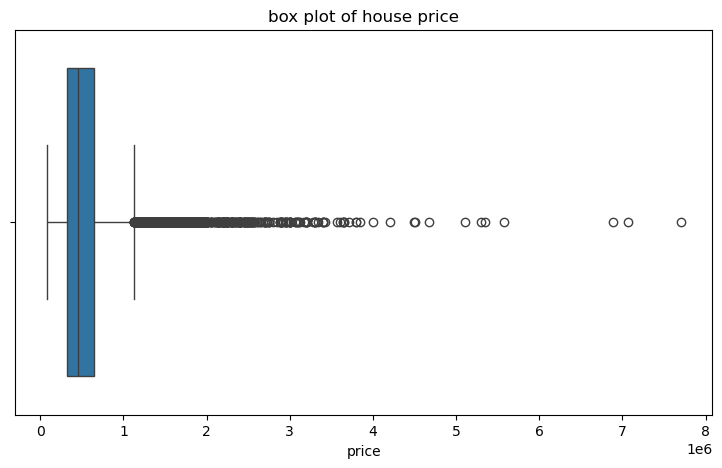

In [28]:
plt.figure(figsize=(9,5))
sns.boxplot(x=df["price"])
plt.title("box plot of house price")
plt.xlabel("price")
plt.show()

In [35]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -162625.0
Upper bound: 1129575.0


In [36]:
print_outliers = df[
    (df["price"] < lower_bound) |
    (df["price"] > upper_bound)
]

print("number of price outliers:", len(print_outliers))

print_outliers[
    ["id", "price", "bedrooms", "bathrooms", "sqft_living"]
].head(20)

number of price outliers: 1146


,id,price,bedrooms,bathrooms,sqft_living
5,7237550310,1225000.0,4.0,4.50,5420
21,2524049179,2000000.0,3.0,2.75,3050
49,822039084,1350000.0,3.0,2.50,2753
69,1802000060,1325000.0,5.0,2.25,3200
125,4389200955,1450000.0,4.0,2.75,2750
153,7855801670,2250000.0,4.0,3.25,5180
216,46100204,1505000.0,5.0,3.00,3300
246,2025069065,2400000.0,4.0,2.50,3650
269,7960900060,2900000.0,4.0,3.25,5050
270,4054500390,1365000.0,4.0,4.75,5310
